# Ensemble Models

- Author: Tulsi Marshall
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: sex

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the penguins dataset.
We choose to predict the target `sex`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05 Modification", level="DEBUG")
log_header(LOG, "M05 Modification")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-01 19:57:43 | INFO | M05 Modification | === RUN START ===
2026-08-01 19:57:43 | INFO | M05 Modification | project=M05 Modification
2026-08-01 19:57:43 | INFO | M05 Modification | repo_dir=ml-05-ensembles
2026-08-01 19:57:43 | INFO | M05 Modification | python=3.14.2
2026-08-01 19:57:43 | INFO | M05 Modification | os=Windows 11
2026-08-01 19:57:43 | INFO | M05 Modification | shell=powershell
2026-08-01 19:57:43 | INFO | M05 Modification | cwd=notebooks
2026-08-01 19:57:43 | INFO | M05 Modification | github_actions=False
2026-08-01 19:57:43 | INFO | M05 Modification | Confirming installation:
2026-08-01 19:57:43 | INFO | M05 Modification |   python:       3.14.2
2026-08-01 19:57:43 | INFO | M05 Modification |   pandas:       3.0.5
2026-08-01 19:57:43 | INFO | M05 Modification |   numpy:        2.5.1
2026-08-01 19:57:43 | INFO | M05 Modification |   scikit-learn: 1.9.0
2026-08-01 19:57:43 | INFO | M05 Modification |   seaborn:      0.13.2
2026-08-01 19:57:43 | INFO | M05 Modificati

## Section 2. Load and Prepare the Data

In [2]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "sex"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-08-01 19:57:43 | INFO | M05 Modification | Loading dataset: penguins
2026-08-01 19:57:43 | INFO | M05 Modification | Loaded: 344 rows (instances), 7 columns
2026-08-01 19:57:43 | INFO | M05 Modification | Original rows: 344
2026-08-01 19:57:43 | INFO | M05 Modification | Model rows:    333
2026-08-01 19:57:43 | INFO | M05 Modification | Classes in target 'sex': ['Female', 'Male']
2026-08-01 19:57:43 | DEBUG | M05 Modification | Class counts:
sex
Male      168
Female    165
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [3]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-01 19:57:43 | INFO | M05 Modification | Train instances: 266
2026-08-01 19:57:43 | INFO | M05 Modification | Test instances: 67


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [4]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-08-01 19:57:43 | INFO | M05 Modification | Fitting single tree + two ensembles
2026-08-01 19:57:43 | DEBUG | M05 Modification |   fitted: single_tree
2026-08-01 19:57:43 | DEBUG | M05 Modification |   fitted: random_forest
2026-08-01 19:57:43 | DEBUG | M05 Modification |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-01 19:57:43 | INFO | M05 Modification |   single_tree        test accuracy = 0.836
2026-08-01 19:57:43 | INFO | M05 Modification |   random_forest      test accuracy = 0.896
2026-08-01 19:57:43 | INFO | M05 Modification |   gradient_boosting  test accuracy = 0.881
C:\Users\grace\AppData\Local\Temp\ipykernel_45620\2508383203.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_keys, y=y_values, palette="viridis")


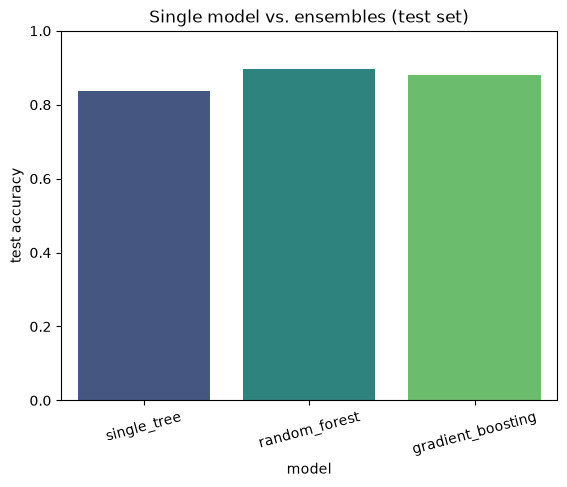

2026-08-01 19:57:44 | INFO | M05 Modification | Best model: random_forest with test accuracy = 0.896


In [5]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.

Code only reports numbers.

Whether an ensemble's gain
is large enough to justify its cost
depends on this specific problem,
and requires analyst judgment.
"""

# score each model on the held-out test set
# accuracy_score returns a numpy scalar - wrap in float() for compatibility
acc_single_tree: float = float(accuracy_score(y_test, modelA.predict(X_test)))
acc_random_forest: float = float(accuracy_score(y_test, modelB.predict(X_test)))
acc_gradient_boosting: float = float(accuracy_score(y_test, modelC.predict(X_test)))

LOG.info(f"  {'single_tree':18s} test accuracy = {acc_single_tree:.3f}")
LOG.info(f"  {'random_forest':18s} test accuracy = {acc_random_forest:.3f}")
LOG.info(f"  {'gradient_boosting':18s} test accuracy = {acc_gradient_boosting:.3f}")

# build a dict for charting
# The keys are the model names,
# and the values are the test accuracies.
scores: dict[str, float] = {
    "single_tree": acc_single_tree,
    "random_forest": acc_random_forest,
    "gradient_boosting": acc_gradient_boosting,
}

# start a new figure
plt.figure()

# create a bar chart of the scores
x_keys = list(scores.keys())
y_values = list(scores.values())

# create a bar chart with seaborn (uses matplotlib under the hood)
sns.barplot(x=x_keys, y=y_values, palette="viridis")

# set y-axis limits to [0, 1] since accuracy is a percentage
plt.ylim(0, 1)

# label the axes and title
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles (test set)")

# slight rotation for readability (optional)
plt.xticks(rotation=15)

# show the plot
plt.show()

# find the best model by name (the one with the highest test accuracy)
best: str = max(scores, key=scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")

### Interpretation

Did the ensemble beat the single tree by enough to justify its cost?

The analyst must decide and defend their choice.

## Section 6. Which Features Did the Forest Rely On?

2026-08-01 19:57:44 | INFO | M05 Modification | Random forest feature importances (high to low):
2026-08-01 19:57:44 | INFO | M05 Modification |   bill_depth_mm        0.356
2026-08-01 19:57:44 | INFO | M05 Modification |   body_mass_g          0.325
2026-08-01 19:57:44 | INFO | M05 Modification |   bill_length_mm       0.203
2026-08-01 19:57:44 | INFO | M05 Modification |   flipper_length_mm    0.116


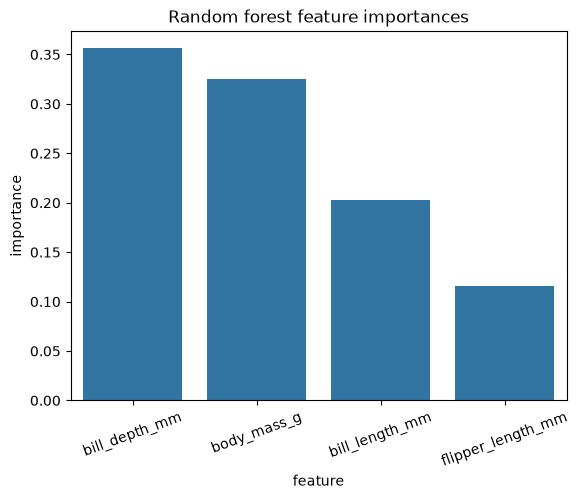

In [6]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

In [7]:
# === Python Summary ===

LOG.info("=========================")
LOG.info("SUMMARY")
LOG.info("=========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info(
    f"Rows: {len(X_train) + len(X_test)} ({len(X_train)} train / {len(X_test)} test)"
)
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
for name, acc in scores.items():
    LOG.info(f"  {name:18s} test accuracy = {acc:.3f}")
LOG.info(f"Best model: {best} ({scores[best]:.3f})")
LOG.info(f"Gain over single tree: {scores[best] - scores['single_tree']:+.3f}")
LOG.info(f"Top feature:     {FEATURE_COLS[order[0]]} ({importances[order[0]]:.3f})")
LOG.info(f"Weakest feature: {FEATURE_COLS[order[-1]]} ({importances[order[-1]]:.3f})")
LOG.info("=========================")

2026-08-01 19:57:44 | INFO | M05 Modification | =========================
2026-08-01 19:57:44 | INFO | M05 Modification | SUMMARY
2026-08-01 19:57:44 | INFO | M05 Modification | =========================
2026-08-01 19:57:44 | INFO | M05 Modification | Dataset: penguins   Target: sex (classification)
2026-08-01 19:57:44 | INFO | M05 Modification | Rows: 333 (266 train / 67 test)
2026-08-01 19:57:44 | INFO | M05 Modification | Compared: single tree vs. random forest vs. gradient boosting
2026-08-01 19:57:44 | INFO | M05 Modification |   single_tree        test accuracy = 0.836
2026-08-01 19:57:44 | INFO | M05 Modification |   random_forest      test accuracy = 0.896
2026-08-01 19:57:44 | INFO | M05 Modification |   gradient_boosting  test accuracy = 0.881
2026-08-01 19:57:44 | INFO | M05 Modification | Best model: random_forest (0.896)
2026-08-01 19:57:44 | INFO | M05 Modification | Gain over single tree: +0.060
2026-08-01 19:57:44 | INFO | M05 Modification | Top feature:     bill_depth_

### Custom Narrative

I changed the target from species to sex. All three models lost accuracy compared with the example, and both ensembles beat the single tree by a wider margin than they did on species, where gradient boosting had no gain at all. The forest relied on bill depth and body mass, the reverse of the species ranking. Body mass carried almost no weight for species at 0.076 and carried the second most for sex at 0.325.

To consider whether the gain is worth the training cost and lost simplicity, I would need some sort of metrics on how we measure and evaluate this. I can measure the gain. I cannot yet measure the cost, because I have not learned how to quantify training time, prediction time or other metrics. I am not sure how to determine the tradeoff. 

### Next Steps

Build a voting classifier combining a decision tree, a support vector machine, and a neural network on the sex target, and compare it against the three models here. Every ensemble in this notebook repeats one model type, while the Project 5 Example instructions include a voting classifier that combines three different types.